# 1) Chargement des données

Allez, cadeau 😘:

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

print("Veuillez uploader le fichier billets.csv :")
uploaded = files.upload()

DATA_PATH = "billets.csv"
if not os.path.exists(DATA_PATH):
    print(f"❌ Attention : le fichier '{DATA_PATH}' n'existe pas.")

try:
    df = pd.read_csv(DATA_PATH, sep=";")
    print("✅ Données chargées :", df.shape)
    display(df.head())
except Exception as e:
    print("❌ Erreur lors du chargement :", e)
    print("⚠️ Tu as bien lu le code avant de l'executer ? 😏")


Veuillez uploader le fichier billets.csv :


Saving billets.csv to billets.csv
✅ Données chargées : (1500, 7)


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


# 2) Analyse exploratoire (EDA)


Là, c'est vous les pro 💪, je vous fais entièrement confiance 😉 !

Pssst (indice) : trouvez des variables corrélées à votre objectif, ça marche mieux 😉.

--- Vérification des valeurs manquantes ---


,0
is_genuine,0
diagonal,0
height_left,0
height_right,0
margin_low,37
margin_up,0
length,0



--- Répartition des Vrais et Faux billets ---


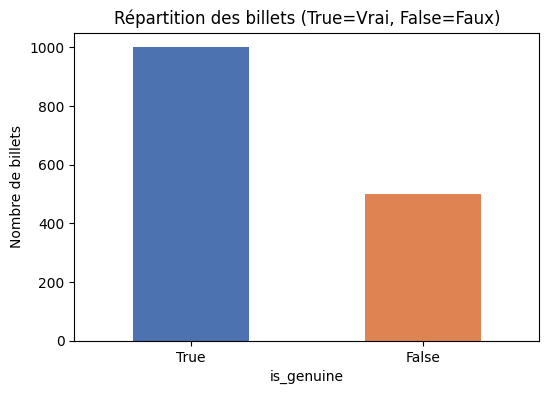


--- Boîtes à moustaches (Boxplots) ---


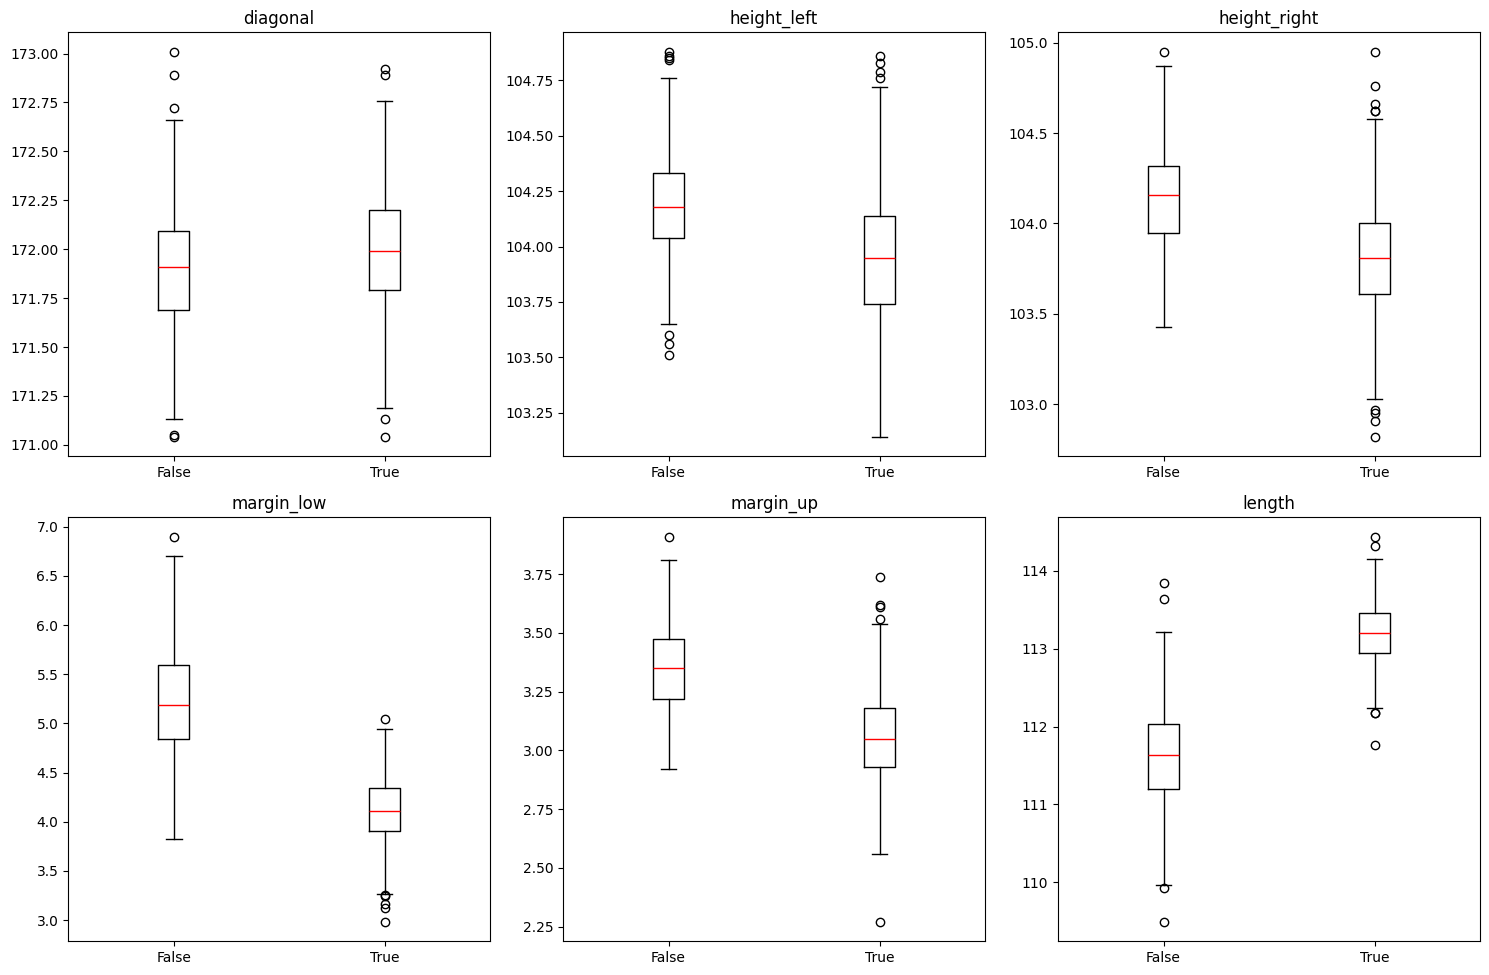


--- Matrice de Corrélation ---


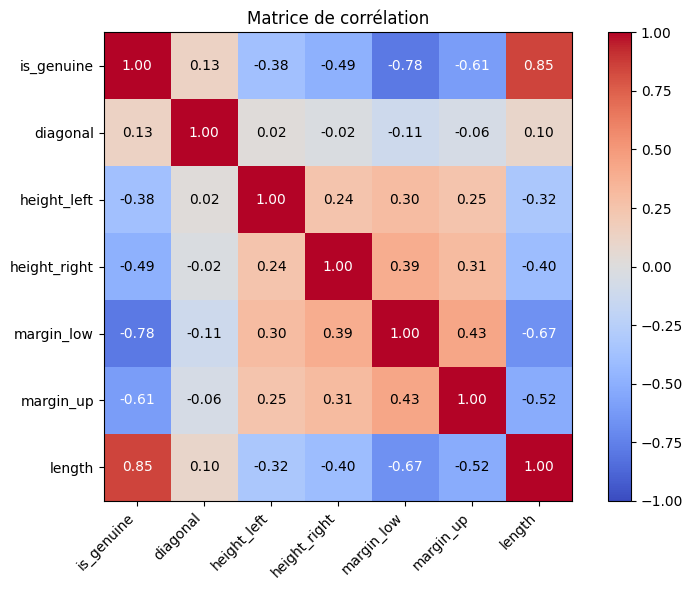

In [ ]:
# 2) Analyse exploratoire (EDA)

print("--- Vérification des valeurs manquantes ---")
display(df.isnull().sum())

print("\n--- Répartition des Vrais et Faux billets ---")
plt.figure(figsize=(6, 4))
df['is_genuine'].value_counts().plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title("Répartition des billets (True=Vrai, False=Faux)")
plt.ylabel("Nombre de billets")
plt.xticks(rotation=0) # Pour garder les labels horizontaux
plt.show()

print("\n--- Boîtes à moustaches (Boxplots) ---")
# Variation des dimensions du billet si il est vrai ou faux
colonnes_dimensions = ['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(colonnes_dimensions):
    df.boxplot(column=col, by='is_genuine', ax=axes[i], grid=False,
               color=dict(boxes='black', whiskers='black', medians='red', caps='black'))
    axes[i].set_title(col)
    axes[i].set_xlabel("")

plt.suptitle("")
plt.tight_layout()
plt.show()

print("\n--- Matrice de Corrélation ---")
# Création d'une matrice de corrélation
corr = df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax)

# Ajout des valeurs numériques
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        couleur_texte = "white" if abs(corr.iloc[i, j]) > 0.6 else "black"
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}",
                ha="center", va="center", color=couleur_texte)

# Configuration des axes
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.linear_model import LinearRegression
from google.colab import files # Import nécessaire pour le téléchargement

features = ['margin_up', 'height_left', 'height_right', 'diagonal', 'length']
target = 'margin_low'

# 1. On sépare les données où margin_low est connu ou non
mask_known   = df[target].notna()
mask_missing = df[target].isna()

X_train = df.loc[mask_known,   features]
y_train = df.loc[mask_known,   target]
X_pred  = df.loc[mask_missing, features]

# 2. On entraîne le modèle de régression linéaire sur les données connues
model = LinearRegression()
model.fit(X_train, y_train)

# 3. On prédit les valeurs manquantes et on les remplace dans le dataframe
df.loc[mask_missing, target] = model.predict(X_pred)

print(f"✅ Les {mask_missing.sum()} valeurs manquantes ont été imputées avec succès !")
print("--- Nouvelle vérification des valeurs manquantes ---")
display(df.isnull().sum())

# 4. Sauvegarde et téléchargement du fichier nettoyé
nom_fichier_propre = "billets_imputes.csv"
df.to_csv(nom_fichier_propre, index=False) # index=False pour garder le format strict

print(f"\n📥 Téléchargement du fichier '{nom_fichier_propre}' en cours...")
files.download(nom_fichier_propre)

✅ Les 37 valeurs manquantes ont été imputées avec succès !
--- Nouvelle vérification des valeurs manquantes ---


,0
is_genuine,0
diagonal,0
height_left,0
height_right,0
margin_low,0
margin_up,0
length,0



📥 Téléchargement du fichier 'billets_imputes.csv' en cours...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 3) Prétraitement

Le but est de transformer tes données brutes (les valeurs mesurées des billets) en données que les algorithmes de Machine Learning peuvent comprendre efficacement.


D'abord, il faut séparer les variables explicatives et la cible :

X = les mesures du billet (longueur, hauteur, diagonales…)

y = l’étiquette (vrai ou faux)

➡️ Pourquoi ?
Parce que le modèle doit apprendre à prédire y en fonction de X.

In [ ]:
# Séparation variables explicatives et cible
X = df.drop(columns=["is_genuine"]) # Toutes les colonnes sauf la cible
y = df["is_genuine"] # La colonne cible

Autre point important : on entraîne toujours le modèle sur un morceau des données, et on teste sur un autre qu’il n’a jamais vu.

➡️ Pourquoi ?
Pour éviter le sur-apprentissage (le modèle apprend par cœur sans savoir généraliser).

In [ ]:
from sklearn.model_selection import train_test_split
# Train/Test split (80% apprentissage, 20% test)
# stratify=y garantit qu'on a la même proportion de vrais/faux dans le train et le test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Enfin, on met toutes les variables sur la même échelle (moyenne = 0, écart-type = 1).

➡️ Pourquoi ?
Parce que certains modèles, comme le KNN ou la Régression Logistique, sont sensibles aux différences d’échelle.
Sans standardisation, la variable la plus grande numériquement prend trop d’importance.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# On fit (calcule moyenne/ecart-type) ET on transforme sur X_train
X_train_scaled = scaler.fit_transform(X_train)
# On transforme SEULEMENT X_test (le modèle ne doit pas apprendre sur les données de test)
X_test_scaled = scaler.transform(X_test)

print(f"Dimensions de X_train_scaled : {X_train_scaled.shape}")
print(f"Dimensions de X_test_scaled : {X_test_scaled.shape}")

Dimensions de X_train_scaled : (1200, 6)
Dimensions de X_test_scaled : (300, 6)


# 4) Modélisation

Dans tous domaines, vous ne pouvez pas progresser si vous ne comprenez pas comment vos outils fonctionnent.

Avant d'utiliser les modèles mathématiques qui suivent, je vous recommande donc de visionner les vidéos suivantes:
* [StatQuest: Logistic Regression](https://www.youtube.com/watch?v=yIYKR4sgzI8)
* [StatQuest: K-nearest neighbors, Clearly Explained](https://youtu.be/HVXime0nQeI)
* [StatQuest: Random Forests Part 1 - Building, Using and Evaluating](https://youtu.be/J4Wdy0Wc_xQ)
* [StatQuest: Random Forests Part 2: Missing data and clustering](https://www.youtube.com/watch?v=sQ870aTKqiM)
* [StatQuest: K-means clustering](https://youtu.be/4b5d3muPQmA)

In [ ]:
from sklearn.linear_model import LogisticRegression

# 1) Initialisez une régression logistic.
    # Quels sont les paramètres ajustables de ce modèle ?
    # Bien que vous puissez laisser la majorité d'entre eux par défaut,
    # il vaut mieux, à minima, ajuster `max_iter` pour plafonner le temps de calcul.

lr=LogisticRegression(max_iter=100, random_state=1)

# 2) Entrainez le modèle avec vos données X_train et y_train

lr.fit(X_train_scaled, y_train)

# 3) Utiliser la régression logistique pour déterminer les vrais / faux billets de X_test.

y_pred_lr=lr.predict(X_test_scaled)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Répéter les même étapes que pour la régression logistique mais avec le KNN.

# 1) Initialisation : on choisit un nombre de voisins impair (souvent 5 par défaut)
# pour éviter les cas d'égalité lors des votes.
knn = KNeighborsClassifier(n_neighbors=5)

# 2) Entraînement avec les données standardisées
knn.fit(X_train_scaled, y_train)

# 3) Prédictions
y_pred_knn = knn.predict(X_test_scaled)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# hum... devinez ce qu'il faut faire 😁.

# 1) Initialisation : on choisit par exemple de créer 100 arbres (n_estimators)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# 2) Entraînement
rf.fit(X_train_scaled, y_train)

# 3) Prédictions
y_pred_rf = rf.predict(X_test_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Assignation automatique : Cluster 1 = Vrais billets | Cluster 0 = Faux billets

Matrice de confusion K-Means (y_test vs K-Means mappé) :
[[ 98   2]
 [  2 198]]


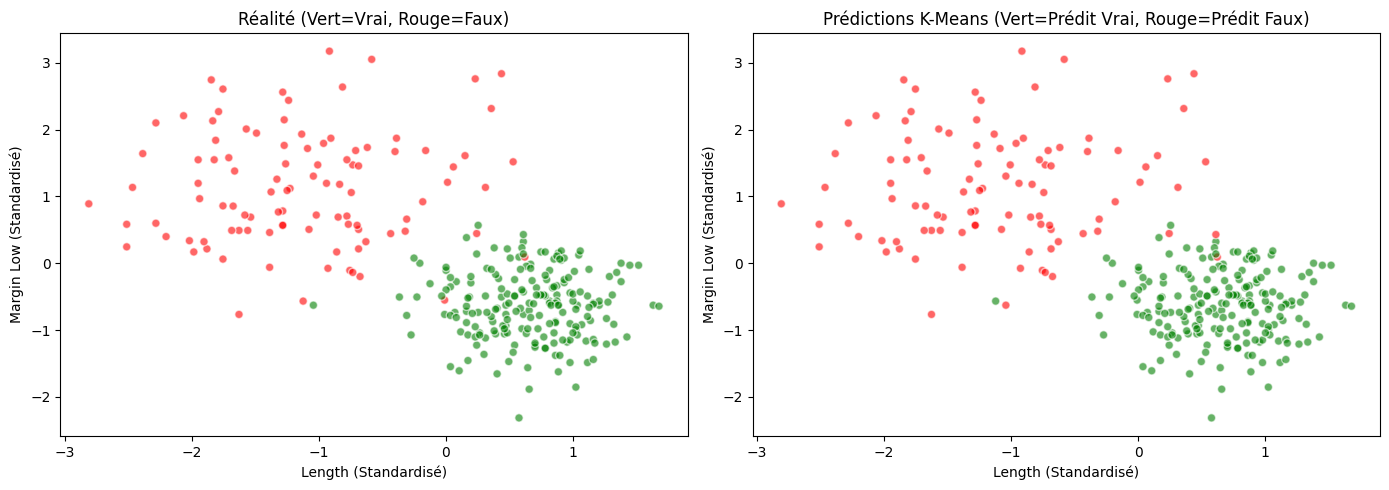

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Attention ! Cet algo est très différent de ceux utilisés précédemment.
# Peux-tu voir les différences ?
# Du coup, cet algo est-il utile (voir pertinent) pour cette étude ?

# 1) Initialisation et entraînement (Non-supervisé : X_train_scaled uniquement)
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
kmeans.fit(X_train_scaled)

# 2) Mapping automatique des clusters (Identification des centroïdes)
# On regarde le centre des vrais billets d'entrainements et quel est le cluster prédit
cluster_vrais = kmeans.predict(scaler.transform(X_train[y_train].mean().values.reshape(1, -1)))[0]

# On regarde le centre des faux billets d'entrainements et quel est le cluster prédit
cluster_faux = kmeans.predict(scaler.transform(X_train[~y_train].mean().values.reshape(1, -1)))[0]

print(f"Assignation automatique : Cluster {cluster_vrais} = Vrais billets | Cluster {cluster_faux} = Faux billets\n")

# 3) Prédiction brute sur le jeu de test (sort des 0 et des 1)
y_pred_kmeans_brut = kmeans.predict(X_test_scaled)

# 4) Remapping des prédictions en True / False
# Si le point appartient au 'cluster_vrais', on lui assigne True. Sinon, False.
y_pred_kmeans = (y_pred_kmeans_brut == cluster_vrais)

# 5) Affichage de la matrice de confusion corrigée
print("Matrice de confusion K-Means (y_test vs K-Means mappé) :")
print(confusion_matrix(y_test, y_pred_kmeans))

# --- VISUALISATION ---
idx_margin_low = 3
idx_length = 5

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Graphique de gauche : Réalité (y_test)
couleurs_realite = ['green' if val else 'red' for val in y_test]
ax1.scatter(X_test_scaled[:, idx_length], X_test_scaled[:, idx_margin_low],
            c=couleurs_realite, alpha=0.6, edgecolors='w')
ax1.set_title("Réalité (Vert=Vrai, Rouge=Faux)")
ax1.set_xlabel("Length (Standardisé)")
ax1.set_ylabel("Margin Low (Standardisé)")

# Graphique de droite : Clusters K-Means MAPPÉS (y_pred_kmeans)
# On utilise maintenant le même code couleur puisque les valeurs sont devenues True/False
couleurs_kmeans = ['green' if val else 'red' for val in y_pred_kmeans]
ax2.scatter(X_test_scaled[:, idx_length], X_test_scaled[:, idx_margin_low],
            c=couleurs_kmeans, alpha=0.6, edgecolors='w')
ax2.set_title("Prédictions K-Means (Vert=Prédit Vrai, Rouge=Prédit Faux)")
ax2.set_xlabel("Length (Standardisé)")
ax2.set_ylabel("Margin Low (Standardisé)")

plt.tight_layout()
plt.show()

# Sélection du meilleur modèle

Mais alors, quel est le meilleur modèle pour résoudre ce problème ?

Pour répondre à cette question, il vous faut bien comprendre l'intérêt de chacune des métriques d'évaluation qui existent pour ce type de problème.

Vous me voyez venir... 😎 : StatQuest !!! 🤩
* [Machine Learning Fundamentals: Sensitivity and Specificity
](https://youtu.be/vP06aMoz4v8)
* [Machine Learning Fundamentals: The Confusion Matrix](https://youtu.be/Kdsp6soqA7o)
* [ROC and AUC, Clearly Explained!](https://youtu.be/4jRBRDbJemM)

Vous avez aussi des petits modules sympathiques sur Sklearn qui vous machent grandement le travail:
* [Confusion Matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)
* [Confusion Matrix Display](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html)
* [Classification Report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)

A vous de jouer ! 🚀


📊 ÉVALUATION DU MODÈLE : Régression Logistique
▶ Accuracy (Exactitude) : 0.9900
▶ Precision (Précision) : 0.9900
▶ Recall (Rappel)       : 0.9950
▶ Score F1              : 0.9925
▶ Score ROC AUC         : 0.9995

--- Classification Report ---
              precision    recall  f1-score   support

       False       0.99      0.98      0.98       100
        True       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300


📊 ÉVALUATION DU MODÈLE : KNN
▶ Accuracy (Exactitude) : 0.9833
▶ Precision (Précision) : 0.9851
▶ Recall (Rappel)       : 0.9900
▶ Score F1              : 0.9875
▶ Score ROC AUC         : 0.9972

--- Classification Report ---
              precision    recall  f1-score   support

       False       0.98      0.97      0.97       100
        True       0.99      0.99      0.99       200

    accuracy                           

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


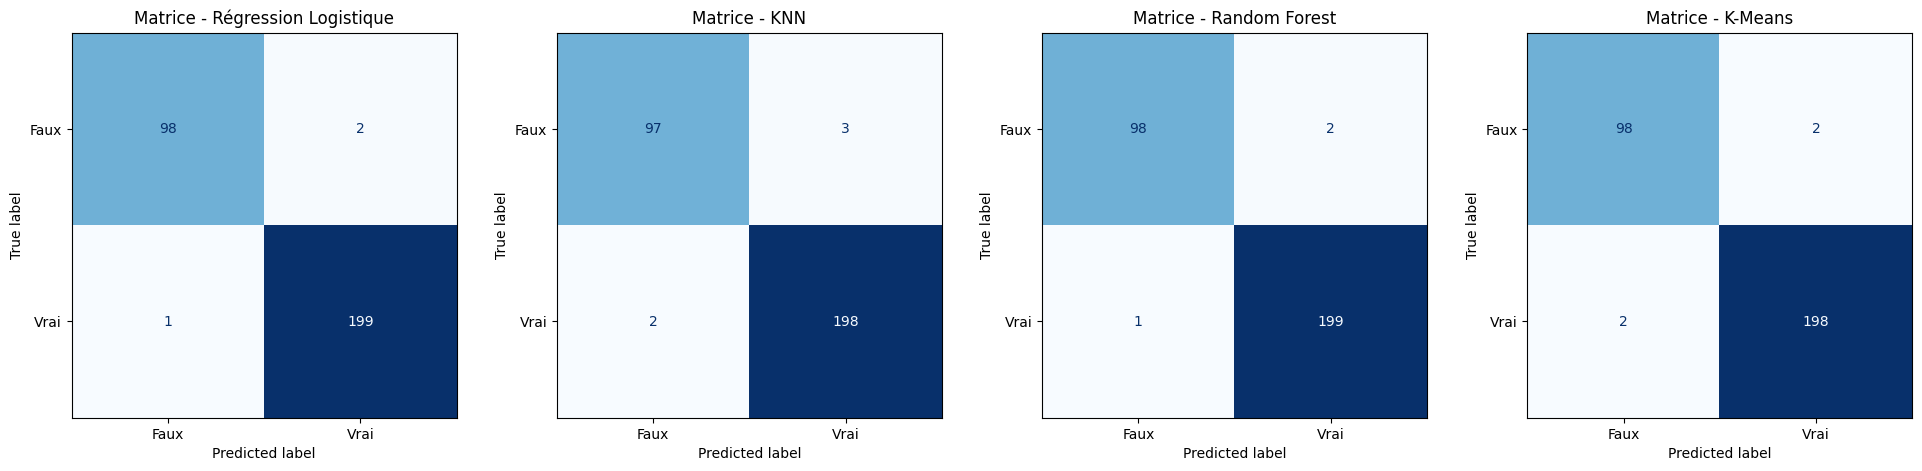

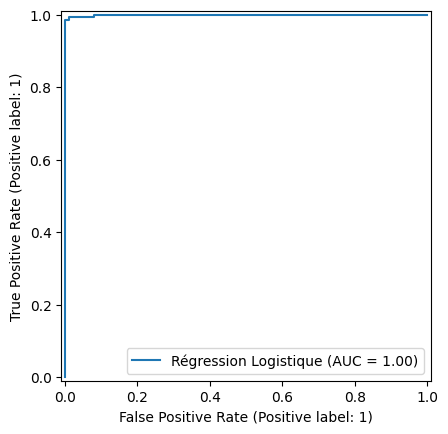

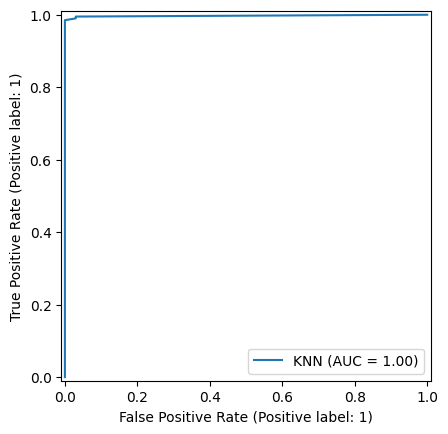

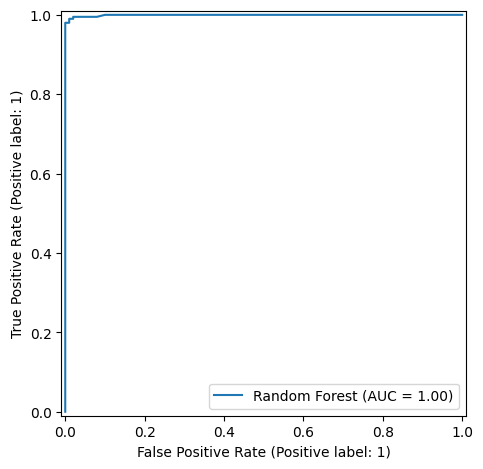

In [ ]:
# Sélection du meilleur modèle

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, RocCurveDisplay
import matplotlib.pyplot as plt

# Rassemblement de tous les modèles à évaluer dans un dictionnaire
modeles_a_evaluer = {
    "Régression Logistique": lr,
    "KNN": knn,
    "Random Forest": rf,
    "K-Means": kmeans
}

# Création de la figure pour les 4 matrices (1 ligne, 4 colonnes)
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for i, (nom, modele) in enumerate(modeles_a_evaluer.items()):
    print(f"\n{'='*50}")
    print(f"📊 ÉVALUATION DU MODÈLE : {nom}")
    print(f"{'='*50}")

    # 1. Calcul des prédictions (True / False ou 0 / 1 pour K-Means)
    y_pred = modele.predict(X_test_scaled)

    # ⚠️ APPLICATION DU MAPPING DU MENTOR POUR LE K-MEANS ⚠️
    if nom == "K-Means":
        # On détermine quel cluster (0 ou 1) correspond aux Vrais billets
        cluster_vrais = modele.predict(scaler.transform(X_train[y_train].mean().values.reshape(1, -1)))[0]
        # On convertit les clusters 0/1 en True/False
        y_pred = (y_pred == cluster_vrais)

    # --- AFFICHAGE DES MÉTRIQUES INDIVIDUELLES ---
    print(f"▶ Accuracy (Exactitude) : {accuracy_score(y_test, y_pred):.4f}")
    print(f"▶ Precision (Précision) : {precision_score(y_test, y_pred):.4f}")
    print(f"▶ Recall (Rappel)       : {recall_score(y_test, y_pred):.4f}")
    print(f"▶ Score F1              : {f1_score(y_test, y_pred):.4f}")

    # 2. Gestion de l'exception pour le calcul des probabilités (AUC-ROC)
    try:
        # Tente de calculer les probabilités (fonctionnera pour LR, KNN, RF)
        y_proba = modele.predict_proba(X_test_scaled)[:, 1]
        print(f"▶ Score ROC AUC         : {roc_auc_score(y_test, y_proba):.4f}\n")

        # Affichage de la courbe ROC
        RocCurveDisplay.from_predictions(y_test, y_proba, name=nom)

    except AttributeError:
        # Si le modèle n'a pas d'attribut 'predict_proba' (ex: K-Means), on gère l'erreur ici
        print("▶ Score ROC AUC         : Non applicable (Pas de probabilités pour ce modèle)\n")

    # --- LE RAPPORT COMPLET ---
    print("--- Classification Report ---")
    print(classification_report(y_test, y_pred))

    # --- LA MATRICE DE CONFUSION ---
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Faux", "Vrai"])
    disp.plot(cmap='Blues', ax=axes[i], colorbar=False)
    axes[i].set_title(f"Matrice - {nom}")

plt.tight_layout()
plt.show()

# Sauvegarde du meilleur modèle

**_ATTENTION_** :
```
Sauvegarder un modèle implique de sauvegarder aussi les étapes de préprocessing des données.
Dans votre cas, vous devez donc inclure, à minima, votre StandardScaler.
```
Voir [`make_pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html) pour plus d'infos.

In [ ]:
from sklearn.pipeline import make_pipeline
import joblib
from google.colab import files

# Utilisez make_pipeline pour inclure toutes les étapes nécessaires
# à la prédiction de si un billet est vrai ou faux.
modele_final = make_pipeline(StandardScaler(), LogisticRegression(max_iter=100, random_state=1))

# ATTENTION CRUCIALE :
# On entraîne ce pipeline sur X_train (les données brutes), ET NON PAS sur X_train_scaled.
# Le StandardScaler intégré au pipeline va calculer la moyenne et l'écart-type
# de X_train tout seul, puis passera les données transformées à la régression logistique.
modele_final.fit(X_train, y_train)

# Sauvegardez votre modèle à l'aide de la librairie joblib.
nom_fichier_modele = 'modele_detection_billets.joblib'
joblib.dump(modele_final, nom_fichier_modele)

print(f"✅ Modèle avec préprocessing sauvegardé avec succès sous le nom : '{nom_fichier_modele}'")

# Téléchargement automatique du fichier
print("📥 Téléchargement en cours...")
files.download(nom_fichier_modele)

✅ Modèle avec préprocessing sauvegardé avec succès sous le nom : 'modele_detection_billets.joblib'
📥 Téléchargement en cours...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>